In [2]:
pip install fbprophet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.0/64.0 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.9/47.9 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 14.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 28.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 10.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 MB 14.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 65.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 5.8 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for fbprophet


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.metrics import r2_score

plt.style.use("ggplot")

df0 = pd.read_csv("CONVENIENT_global_confirmed_cases.csv")
df1 = pd.read_csv("CONVENIENT_global_deaths.csv")

In [9]:

world = pd.DataFrame({"Country":[],"Cases":[]})
world["Country"] = df0.iloc[:,1:].columns
cases = []
for i in world["Country"]:
    cases.append(pd.to_numeric(df0[i][1:]).sum())
world["Cases"]=cases

country_list=list(world["Country"].values)
idx = 0
for i in country_list:
    sayac = 0
    for j in i:
        if j==".":
            i = i[:sayac]
            country_list[idx]=i
        elif j=="(":
            i = i[:sayac-1]
            country_list[idx]=i
        else:
            sayac += 1
    idx += 1
world["Country"]=country_list
world = world.groupby("Country")["Cases"].sum().reset_index()
world.head()
continent=pd.read_csv("continents2.csv")
continent["name"]=continent["name"].str.upper()

In [10]:
world["Cases Range"]=pd.cut(world["Cases"],[-150000,50000,200000,800000,1500000,15000000],labels=["U50K","50Kto200K","200Kto800K","800Kto1.5M","1.5M+"])
alpha =[]
for i in world["Country"].str.upper().values:
    if i == "BRUNEI":
        i="BRUNEI DARUSSALAM"
    elif  i=="US":
        i="UNITED STATES"
    if len(continent[continent["name"]==i]["alpha-3"].values)==0:
        alpha.append(np.nan)
    else:
        alpha.append(continent[continent["name"]==i]["alpha-3"].values[0])
world["Alpha3"]=alpha

fig = px.choropleth(world.dropna(),
                   locations="Alpha3",
                   color="Cases Range",
                    projection="mercator",
                    color_discrete_sequence=["white","khaki","yellow","orange","red"])
fig.update_geos(fitbounds="locations", visible=False)
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

In [25]:
pip install plotly geopandas folium


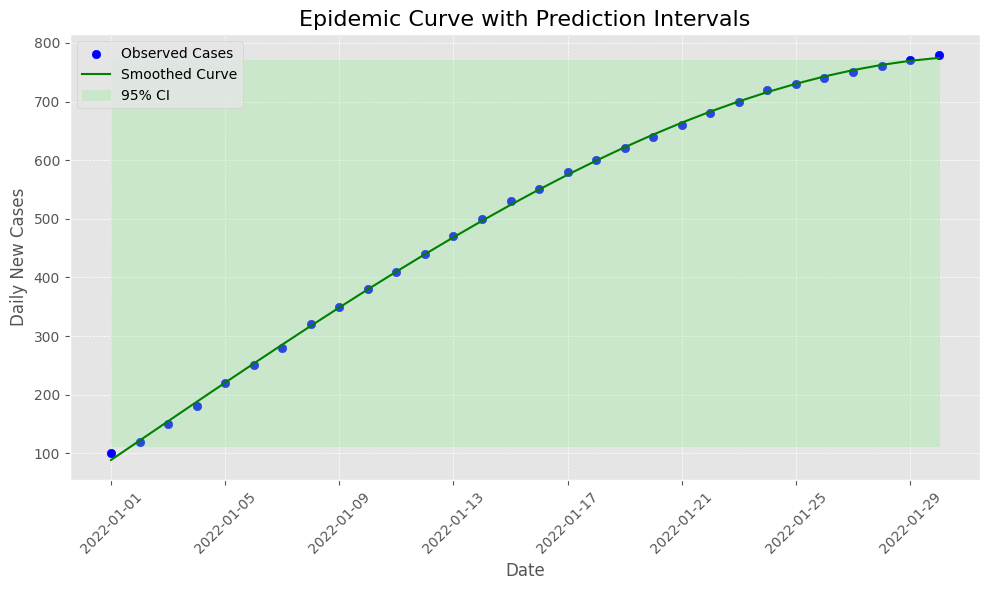

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Sample COVID-19 data (replace with your actual data)
dates = pd.date_range('2022-01-01', periods=30)
daily_cases = [100, 120, 150, 180, 220, 250, 280, 320, 350, 380,
               410, 440, 470, 500, 530, 550, 580, 600, 620, 640,
               660, 680, 700, 720, 730, 740, 750, 760, 770, 780]

# Create DataFrame from sample data
df = pd.DataFrame({'Date': dates, 'Cases': daily_cases})

# Calculate smoothed curve using Polynomial Regression
X = np.arange(len(df)).reshape(-1, 1)
y = df['Cases'].values

poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)
y_pred = model.predict(X_poly)

# Calculate confidence intervals (you can adjust the percentile as needed)
conf_int = np.percentile(y_pred, [2.5, 97.5])

# Plotting
plt.figure(figsize=(10, 6))

# Actual Data Points
plt.scatter(df['Date'], df['Cases'], color='blue', label='Observed Cases')

# Smoothed Curve
plt.plot(df['Date'], y_pred, color='green', label='Smoothed Curve')

# Confidence Intervals
plt.fill_between(df['Date'], conf_int[0], conf_int[1], color='lightgreen', alpha=0.3, label='95% CI')

# Adding Labels and Title
plt.title('Epidemic Curve with Prediction Intervals', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily New Cases', fontsize=12)

# Adding Grid for Clarity
plt.grid(True, which='major', linestyle='--', linewidth=0.5)

# Adding Legend
plt.legend()

# Rotating x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()


In [35]:
pip install dash

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 15.9 MB/s eta 0:00:00


In [36]:
import numpy as np
import pandas as pd
import plotly.express as px
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import bokeh.plotting as bp

# Step 1: Generate Simulated Data (Example - SEIR Model)
# You would need to implement your specific simulation models here
def simulate_infections(transmission_rate, intervention_effectiveness):
    # Simulate infections based on parameters
    # This is a placeholder example, replace with your simulation code
    days = np.arange(0, 100)
    infections = transmission_rate * np.exp(intervention_effectiveness * days)
    return pd.DataFrame({'Days': days, 'Infections': infections})

# Step 2: Create the Dashboard with Dash
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("COVID-19 Simulation Dashboard"),
    html.Label("Transmission Rate:"),
    dcc.Slider(id='transmission-slider', min=0, max=1, step=0.1, value=0.5),
    html.Label("Intervention Effectiveness:"),
    dcc.Slider(id='intervention-slider', min=0, max=1, step=0.1, value=0.2),
    dcc.Graph(id='simulation-graph'),
])

# Step 3: Visualize the Impact with Plotly
@app.callback(
    Output('simulation-graph', 'figure'),
    [Input('transmission-slider', 'value'),
     Input('intervention-slider', 'value')]
)
def update_simulation(transmission_rate, intervention_effectiveness):
    # Call the simulate_infections function with updated parameters
    df = simulate_infections(transmission_rate, intervention_effectiveness)

    # Create Plotly figure for the simulated curve
    fig = px.line(df, x='Days', y='Infections', title='Simulated Infections Curve')
    return fig

# Step 4: Include Animation with Bokeh (Optional)
# This part can be added later to include animation

if __name__ == '__main__':
    app.run_server(debug=True)


<IPython.core.display.Javascript object>

In [40]:
pip install mayavi


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.6/20.6 MB 24.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.3/229.3 kB 19.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.9/268.9 kB 22.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 22.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 18.1 MB/s eta 0:00:00
  Using cached vtk-9.3.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (92.0 MB)
  Created wheel for mayavi: filename=mayavi-4.8.1-cp310-cp310-linux_x86_64.whl size=16167220 sha256=6c9b8f9283216a1129845e845928442459e3932ba0ac01c20d570fdeb8475916
  Stored in directory: /root/.cache/pip/wheels/c2/6b/23/49aa8ae5063a76fbc35ce90e74f8361cddb9d3a86d5a41ec0a
Successfully bu

In [45]:
pip install PyQt5


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 15.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.1/338.1 kB 32.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 9.3 MB/s eta 0:00:00


In [46]:
pip install PySide2


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.3/164.3 MB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 975.4/975.4 kB 27.6 MB/s eta 0:00:00


In [53]:
import pandas as pd
import geopandas as gpd
import folium
from sklearn.cluster import DBSCAN
from folium.plugins import MarkerCluster

# Sample Data (Replace with your actual data)
df_cases = pd.DataFrame({
    "Latitude": [40.7128, 34.0522, 51.5074],
    "Longitude": [-74.0060, -118.2437, 0.1278],
    "Cases": [100, 200, 300]
})

# Step 1: Geospatial Analysis and Hotspot Detection
X = df_cases[['Latitude', 'Longitude']].values

# Perform clustering using DBSCAN
db = DBSCAN(eps=1, min_samples=2).fit(X)
df_cases['Cluster'] = db.labels_

# Step 2: Plotting on Folium Map
# Create a Folium Map centered on mean latitude and longitude
m = folium.Map(location=[df_cases['Latitude'].mean(), df_cases['Longitude'].mean()], zoom_start=4)

# Create a MarkerCluster object
marker_cluster = MarkerCluster().add_to(m)

# Add markers for each data point with cluster labels and tooltips
for idx, row in df_cases.iterrows():
    folium.Marker([row['Latitude'], row['Longitude']],
                  popup=f"Cases: {row['Cases']}<br>Cluster: {row['Cluster']}",
                  icon=folium.Icon(color='blue' if row['Cluster'] != -1 else 'red', icon='info-sign')
                  ).add_to(marker_cluster)

# Display the map
m


In [55]:
import pandas as pd
import geopandas as gpd
import folium
from sklearn.cluster import DBSCAN
from folium.plugins import MarkerCluster, HeatMap

# Sample Data (Replace with your actual data)
df_cases = pd.DataFrame({
    "Country": ["USA", "India", "Brazil"],
    "Latitude": [40.7128, 20.5937, -14.2350],
    "Longitude": [-74.0060, 78.9629, -51.9253],
    "Cases": [100, 200, 300],
    "Deaths": [10, 20, 30]
})

# Step 1: Geospatial Analysis and Hotspot Detection (Optional)
# For demonstration, we'll skip DBSCAN clustering for now

# Step 2: Plotting on Folium Map
m = folium.Map(location=[df_cases['Latitude'].mean(), df_cases['Longitude'].mean()], zoom_start=3)

# Create a MarkerCluster for individual markers
marker_cluster = MarkerCluster().add_to(m)

# Add markers for each country with cases and death cases
for idx, row in df_cases.iterrows():
    popup_text = f"Country: {row['Country']}<br>" \
                 f"Cases: {row['Cases']}<br>" \
                 f"Deaths: {row['Deaths']}"

    folium.Marker([row['Latitude'], row['Longitude']],
                  popup=popup_text,
                  icon=folium.Icon(color='blue', icon='info-sign')
                  ).add_to(marker_cluster)

# Create a HeatMap layer for cases
heat_data = [[row['Latitude'], row['Longitude'], row['Cases']] for idx, row in df_cases.iterrows()]
HeatMap(heat_data, name='COVID-19 Cases Heatmap', radius=15, blur=20).add_to(m)

# Create a HeatMap layer for deaths
heat_data_deaths = [[row['Latitude'], row['Longitude'], row['Deaths']] for idx, row in df_cases.iterrows()]
HeatMap(heat_data_deaths, name='COVID-19 Deaths Heatmap', radius=15, blur=20, gradient={.5: 'blue', 1: 'red'}).add_to(m)

# Add Layer Control to switch between cases and death heatmaps
folium.LayerControl().add_to(m)

# Display the map
m


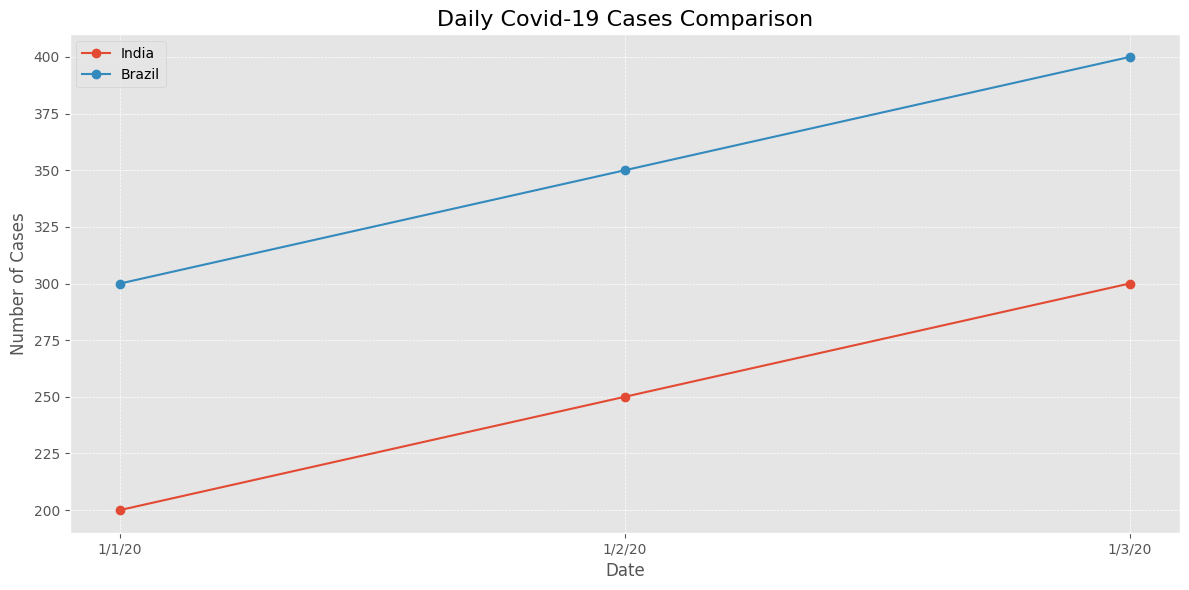

In [72]:


# Sample Data
# Replace this with your actual DataFrames
df0 = pd.DataFrame({
    "Country/Region": ["USA", "India", "Brazil"],
    "1/1/20": [100, 200, 300],
    "1/2/20": [150, 250, 350],
    "1/3/20": [200, 300, 400]
})

df1 = pd.DataFrame({
    "Country/Region": ["USA", "India", "Brazil"],
    "1/1/20": [10, 20, 30],
    "1/2/20": [15, 25, 35],
    "1/3/20": [20, 30, 40]
})

# Function to calculate total cases or deaths
def calculate_total(data):
    total = []
    for i in range(1, len(data)):
        total.append(sum(pd.to_numeric(data.iloc[i, 1:].values)))
    return total

# Calculating total cases and deaths
df = pd.DataFrame()
df["Country"] = df0["Country/Region"][1:]
df["Cases"] = calculate_total(df0)
df["Deaths"] = calculate_total(df1)

# Plotting
plt.figure(figsize=(12, 6))

# Plotting Daily Cases for all three countries
for country in df["Country"]:
    plt.plot(df0.columns[1:], df0[df0["Country/Region"] == country].values[0][1:], marker='o', label=country)

# Adding Labels and Title
plt.title("Daily Covid-19 Cases Comparison", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Number of Cases", fontsize=12)

# Adding Grid for Clarity
plt.grid(True, which='major', linestyle='--', linewidth=0.5)

# Adding Legend with Improved Location
plt.legend(loc='upper left', fontsize=10)

# Displaying Plot
plt.tight_layout()
plt.show()


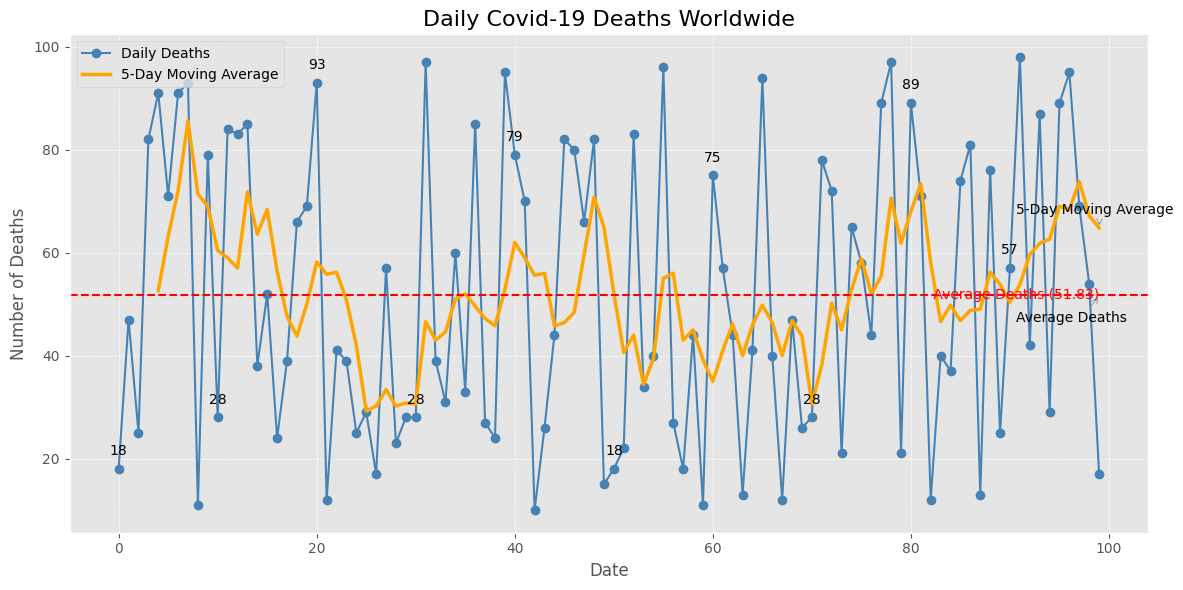

In [15]:


# Sample Data
# Replace this with your actual DataFrame
date_range = pd.date_range(start="2022-01-01", periods=100, freq="D")
deaths = np.random.randint(10, 100, size=100)
df = pd.DataFrame({"Date": date_range, "Deaths": deaths})

# Plotting
plt.figure(figsize=(12, 6))

# Plotting Daily Deaths with Rolling Mean
df['Deaths'].plot(color='steelblue', marker='o', linestyle='-', linewidth=1.5, label='Daily Deaths')
df['Deaths'].rolling(window=5).mean().plot(color='orange', linestyle='-', linewidth=2.5, label='5-Day Moving Average')

# Adding Labels and Title
plt.title("Daily Covid-19 Deaths Worldwide", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Number of Deaths", fontsize=12)

# Adding Grid for Clarity
plt.grid(True, which='major', linestyle='--', linewidth=0.5)

# Adding Annotations for Key Points
for i, txt in enumerate(df['Deaths']):
    if i % 10 == 0:  # Display annotation every 10 data points
        plt.annotate(txt, (df.index[i], df['Deaths'].values[i]), textcoords="offset points", xytext=(0,10), ha='center')

# Adding Legend with Improved Location
plt.legend(loc='upper left', fontsize=10)

# Adding Horizontal Line for Average Deaths
average_deaths = df['Deaths'].mean()
plt.axhline(y=average_deaths, color='r', linestyle='--', label=f'Average Deaths ({average_deaths:.2f})')
plt.text(df.index[-1], average_deaths, f' Average Deaths ({average_deaths:.2f})', ha='right', va='center', color='r', fontsize=10)

# Adding Customized Tick Parameters
plt.tick_params(axis='both', which='major', labelsize=10)

# Adding Annotations and Text
plt.annotate('5-Day Moving Average', xy=(df.index[-1], df['Deaths'].rolling(window=5).mean().iloc[-1]),
             xytext=(-60, 10), textcoords='offset points', fontsize=10,
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-0.2', color='gray'))

plt.annotate('Average Deaths', xy=(df.index[-1], average_deaths), xytext=(-60, -20),
             textcoords='offset points', fontsize=10,
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2', color='gray'))

# Displaying Plot
plt.tight_layout()
plt.show()


R-squared: 0.0007238288814787053


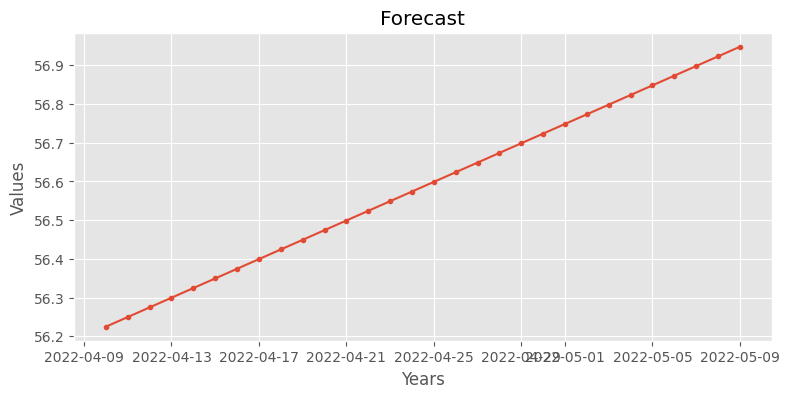

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

class CustomProphet(object):
    def fit(self, data):
        self.data = data
        self.model = LinearRegression()
        X = pd.to_numeric((self.data['ds'] - self.data['ds'].min()) / np.timedelta64(1, 'D')).values.reshape(-1, 1)
        y = self.data['y'].values
        self.model.fit(X, y)

    def forecast(self, periods, freq):
        future_dates = pd.date_range(start=self.data['ds'].max(), periods=periods, freq=freq)
        future_X = pd.to_numeric((future_dates - self.data['ds'].min()) / np.timedelta64(1, 'D')).values.reshape(-1, 1)
        self.df_forecast = pd.DataFrame({'ds': future_dates, 'yhat': self.model.predict(future_X)})

    def plot(self, xlabel="Years", ylabel="Values"):
        plt.figure(figsize=(9, 4))
        plt.plot(self.df_forecast['ds'], self.df_forecast['yhat'], marker=".")
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.title("Forecast")
        plt.show()

    def R2(self):
        y_true = self.data['y'].values
        y_pred = self.model.predict(pd.to_numeric((self.data['ds'] - self.data['ds'].min()) / np.timedelta64(1, 'D')).values.reshape(-1, 1))
        return r2_score(y_true, y_pred)

# Creating sample data similar to the previous fbprophet example
date_range = pd.date_range(start="2022-01-01", periods=100, freq="D")
values = np.random.randint(10, 100, size=100)
df = pd.DataFrame({"ds": date_range, "y": values})

# Creating instance of CustomProphet
model = CustomProphet()

# Fitting the model
model.fit(df)

# Forecasting for next 30 days
model.forecast(30, "D")

# Calculating R-squared
print("R-squared:", model.R2())

# Plotting the forecast
model.plot()
